# Orbits: Monty integrates, three.js draws

An agent asked for "a 3D picture of the figure-eight three-body orbit with a few test particles"
writes two programs, because each language has a job it is good at:

- **Python, in Monty** (pydantic's Python sandbox): the physics. A symplectic velocity-Verlet
  (leapfrog) integrator, pure `math`: the Chenciner-Montgomery figure-eight choreography plus
  three light test particles, a few thousand steps, and the total energy tracked as it goes.
- **JavaScript, in pydeno** (a worker process behind an OS sandbox): the 3D. three.js fits a
  `CatmullRomCurve3` through each trajectory, sweeps a `TubeGeometry` trail along it painted by
  speed with vertex colours, puts a sphere at every body's end position, measures each path, finds
  the closest approach between every pair of bodies, and exports a binary glTF (`.glb`).

Both halves run without trusting either: neither can touch your files, network or environment.
The only things they can call are the host functions you hand them.

```
pip install pydeno pydantic-monty
```


Imports and the Monty import guard from the original script.

In [1]:
import asyncio
import pathlib
import sys
import time
from typing import Any

from pydeno import WEB_POLYFILLS, IsolatedRuntime, RuntimeConfig

try:
    from pydantic_monty import Monty
except ImportError:
    sys.exit("This example pairs pydeno with Monty: pip install pydantic-monty")


Notebook-only: `OrbitsPipeline.render` below calls `asyncio.run(...)`, which assumes no event loop is already running -- true for a plain script, false inside a Jupyter kernel. `nest_asyncio` patches that so the class body can stay verbatim.

In [2]:
import nest_asyncio

nest_asyncio.apply()


Paths to the vendored three.js bundle, and the step counts worth benchmarking (the time step is fixed, so more steps is more simulated time). In the notebook, the repo root stands in for `pathlib.Path(__file__).resolve().parent.parent` from the script.

In [3]:
def _repo_root() -> pathlib.Path:
    """Walk up from the current directory to find the pydeno checkout: this notebook is run
    with the repo root as its cwd when executed from the command line, but opening it directly
    in Jupyter normally starts in its own directory (examples/notebooks/) instead."""
    for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (candidate / "vendor" / "libs").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside a pydeno checkout")


LIBS = _repo_root() / "vendor" / "libs"
THREE_BUNDLE = "three-0.180.0-gltf.bundle.js"

SIZES = [500, 1500, 3000, 6000]
DT = 0.0025


The Python half (what the model wrote). It runs in Monty: no imports beyond `math`, no files.

In [4]:
MODEL_PYTHON = """
import math

EPS2 = 0.0001  # softening, so a close pass cannot blow the integrator up

masses = [1.0, 1.0, 1.0, 0.001, 0.001, 0.001]
pos = [
    [0.97000436, -0.24308753, 0.0],
    [-0.97000436, 0.24308753, 0.0],
    [0.0, 0.0, 0.0],
    [2.0, 0.0, 0.3],
    [0.0, -1.7, -0.2],
    [-1.6, 1.0, 0.1],
]
vel = [
    [0.466203685, 0.43236573, 0.0],
    [0.466203685, 0.43236573, 0.0],
    [-0.93240737, -0.86473146, 0.0],
    [0.0, 0.87, 0.0],
    [1.33, 0.0, 0.0],
    [-0.7, -1.1, 0.0],
]
n = len(masses)


def accelerations(pos):
    acc = [[0.0, 0.0, 0.0] for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            dx = pos[j][0] - pos[i][0]
            dy = pos[j][1] - pos[i][1]
            dz = pos[j][2] - pos[i][2]
            r2 = dx * dx + dy * dy + dz * dz + EPS2
            inv = 1.0 / (r2 * math.sqrt(r2))
            for k, d in enumerate((dx, dy, dz)):
                acc[i][k] += masses[j] * d * inv
                acc[j][k] -= masses[i] * d * inv
    return acc


def energy(pos, vel):
    e = 0.0
    for i in range(n):
        v = vel[i]
        e += 0.5 * masses[i] * (v[0] * v[0] + v[1] * v[1] + v[2] * v[2])
        for j in range(i + 1, n):
            dx = pos[j][0] - pos[i][0]
            dy = pos[j][1] - pos[i][1]
            dz = pos[j][2] - pos[i][2]
            e -= masses[i] * masses[j] / math.sqrt(dx * dx + dy * dy + dz * dz + EPS2)
    return e


stride = max(1, STEPS // 200)
e0 = energy(pos, vel)
drift = 0.0
paths = [[[p[0], p[1], p[2]]] for p in pos]
speeds = [[math.sqrt(v[0] * v[0] + v[1] * v[1] + v[2] * v[2])] for v in vel]
acc = accelerations(pos)
for step in range(1, STEPS + 1):
    for i in range(n):
        for k in range(3):
            vel[i][k] += 0.5 * DT * acc[i][k]
            pos[i][k] += DT * vel[i][k]
    acc = accelerations(pos)
    for i in range(n):
        for k in range(3):
            vel[i][k] += 0.5 * DT * acc[i][k]
    if step % stride == 0 or step == STEPS:
        drift = max(drift, abs((energy(pos, vel) - e0) / e0))
        for i in range(n):
            paths[i].append([pos[i][0], pos[i][1], pos[i][2]])
            v = vel[i]
            speeds[i].append(math.sqrt(v[0] * v[0] + v[1] * v[1] + v[2] * v[2]))

{
    "steps": STEPS,
    "dt": DT,
    "masses": masses,
    "paths": paths,
    "speeds": speeds,
    "energy0": e0,
    "energy_end": energy(pos, vel),
    "drift": drift,
}
"""

The JavaScript half. It runs in pydeno with three.js loaded; `getOrbits()` is the host function that hands it the Python result, and the only way in.

In [5]:
MODEL_JAVASCRIPT = """
globalThis.buildScene = () => {
  const { masses, paths, speeds, drift, energy0, energy_end } = getOrbits();
  const pts = paths.map((p) => p.map(([x, y, z]) => new THREE.Vector3(x, y, z)));
  const samples = pts[0].length;
  const radial = 5;

  let lo = Infinity, hi = -Infinity;
  for (const s of speeds) for (const v of s) { lo = Math.min(lo, v); hi = Math.max(hi, v); }
  const ramp = (v) => {                       // slow = blue, fast = red
    const t = (v - lo) / (hi - lo || 1);
    return [t, 0.25 + 0.5 * (1 - Math.abs(2 * t - 1)), 1 - t];
  };

  const scene = new THREE.Scene();
  const pathLength = [];
  masses.forEach((m, b) => {
    // Cumulative arc length at each sample, to find the speed at any fraction of the trail.
    const cum = [0];
    for (let i = 1; i < samples; i++) cum.push(cum[i - 1] + pts[b][i].distanceTo(pts[b][i - 1]));
    pathLength.push(cum[samples - 1]);
    const speedAt = (u) => {
      const s = u * cum[samples - 1];
      let i = 1;
      while (i < samples - 1 && cum[i] < s) i++;
      const w = (s - cum[i - 1]) / ((cum[i] - cum[i - 1]) || 1);
      return speeds[b][i - 1] + (speeds[b][i] - speeds[b][i - 1]) * Math.min(1, Math.max(0, w));
    };

    const curve = new THREE.CatmullRomCurve3(pts[b]);
    const tube = new THREE.TubeGeometry(curve, samples - 1, m > 0.1 ? 0.025 : 0.012, radial, false);
    const colors = new Float32Array(tube.attributes.position.count * 3);
    for (let k = 0; k < tube.attributes.position.count; k++) {
      const ring = Math.floor(k / (radial + 1));
      colors.set(ramp(speedAt(ring / (samples - 1))), k * 3);
    }
    tube.setAttribute('color', new THREE.BufferAttribute(colors, 3));
    scene.add(new THREE.Mesh(tube, new THREE.MeshStandardMaterial({ vertexColors: true })));
  });

  masses.forEach((m, b) => {
    const ball = new THREE.Mesh(
      new THREE.SphereGeometry(m > 0.1 ? 0.07 : 0.035, 16, 12),
      new THREE.MeshStandardMaterial({ color: m > 0.1 ? 0xffd166 : 0xe8e8e8 }));
    ball.position.copy(pts[b][samples - 1]);
    scene.add(ball);
  });
  scene.updateMatrixWorld(true);
  globalThis.__scene = scene;

  // Closest approach of every pair, by plain vector maths over the sampled trajectories.
  const closest = [];
  for (let a = 0; a < masses.length; a++) {
    for (let b = a + 1; b < masses.length; b++) {
      let best = Infinity, at = 0;
      for (let i = 0; i < samples; i++) {
        const d = pts[a][i].distanceTo(pts[b][i]);
        if (d < best) { best = d; at = i; }
      }
      closest.push({ a, b, distance: best, sample: at });
    }
  }
  const box = new THREE.Box3().setFromObject(scene);
  return {
    bodies: masses.length, samples, pathLength, closest, drift, energy0, energyEnd: energy_end,
    speed: [lo, hi], bounds: [box.min.toArray(), box.max.toArray()],
  };
};

globalThis.exportGlb = () => new Promise((resolve, reject) =>
  new GLTFExporter().parse(globalThis.__scene, resolve, reject, { binary: true }));
"""

One Monty pool and one warm pydeno runtime, reused across simulations.

In [6]:
class OrbitsPipeline:
    """One Monty pool and one warm pydeno runtime, reused across simulations."""

    def __init__(self, *, jitless: bool = True) -> None:
        self.monty = Monty().__enter__()
        self.rt = IsolatedRuntime(
            RuntimeConfig(bootstrap=WEB_POLYFILLS, timeout=120.0),
            sandbox="require",
            request_timeout=300,
            jitless=jitless,
        )
        self._orbits: dict[str, Any] = {}
        self.rt.bind_function("getOrbits", lambda: self._orbits)
        self.load_seconds = 0.0

    def load_three(self) -> None:
        start = time.perf_counter()
        self.rt.eval((LIBS / THREE_BUNDLE).read_text() + "\n;0")
        self.rt.eval(MODEL_JAVASCRIPT + "\n;0")
        self.load_seconds = time.perf_counter() - start

    def prepare(self, steps: int, dt: float = DT) -> dict[str, Any]:
        """Python half, in Monty."""
        with self.monty.checkout() as session:
            return session.feed_run(MODEL_PYTHON, inputs={"STEPS": steps, "DT": dt})

    def render(self, steps: int) -> tuple[bytes, dict[str, Any], dict[str, float]]:
        t0 = time.perf_counter()
        self._orbits = self.prepare(steps)
        t1 = time.perf_counter()
        stats = self.rt.eval("buildScene()")
        t2 = time.perf_counter()
        glb = asyncio.run(self.rt.eval_async("exportGlb()", timeout=300))
        t3 = time.perf_counter()
        return (
            bytes(glb),
            stats,
            {
                "monty_prepare": t1 - t0,
                "three_build": t2 - t1,
                "glb_export": t3 - t2,
                "total": t3 - t0,
            },
        )

    def close(self) -> None:
        self.rt.close()
        self.monty.__exit__(None, None, None)

Build the pipeline, load three.js into the sandbox, and run the simulation.

In [7]:
steps = 3000
pipe = OrbitsPipeline()
print(f"sandbox: {pipe.rt.sandbox}")
pipe.load_three()
print(f"three.js loaded into the sandbox in {pipe.load_seconds * 1000:.0f} ms")


sandbox: seatbelt
three.js loaded into the sandbox in 28 ms


Run the Monty physics step and the pydeno/three.js build-and-export step, and report timings.

In [8]:
glb, stats, t = pipe.render(steps)
out_path = pathlib.Path("orbits.glb")  # written next to this notebook
out_path.write_bytes(glb)
tightest = min(stats["closest"], key=lambda c: c["distance"])
print(
    f"{steps} steps -> {stats['bodies']} bodies, {stats['samples']} samples each, "
    f"energy drift {stats['drift']:.2e}"
)
print(
    f"  closest pair: bodies {tightest['a']} and {tightest['b']} "
    f"at {tightest['distance']:.4f}"
)
print(f"  monty prepared the data   {t['monty_prepare'] * 1000:8.0f} ms")
print(f"  three.js built the scene  {t['three_build'] * 1000:8.0f} ms")
print(f"  glTF export               {t['glb_export'] * 1000:8.0f} ms")
print(f"wrote {out_path} ({len(glb) / 1024:.0f} KiB) in {t['total'] * 1000:.0f} ms total")


3000 steps -> 6 bodies, 201 samples each, energy drift 2.17e-05
  closest pair: bodies 0 and 3 at 0.0658
  monty prepared the data        162 ms
  three.js built the scene        52 ms
  glTF export                     50 ms
wrote orbits.glb (450 KiB) in 264 ms total


Close the pipeline: shut down the pydeno runtime and the Monty pool.

In [9]:
pipe.close()

The `.glb` above is a binary glTF scene; notebooks can't render it inline without extra viewer JS, so this confirms it was written and shows the pre-rendered preview instead.

In [10]:
glb_size = out_path.stat().st_size
assert glb_size > 0, "orbits.glb is empty"
print(f"orbits.glb written: {glb_size / 1024:.0f} KiB at {out_path}")


orbits.glb written: 450 KiB at orbits.glb


**Preview** (rendered ahead of time with three.js from the exported `.glb`): an N-body simulation. Monty integrates the orbits; three.js turns each trail into a speed-coloured tube.

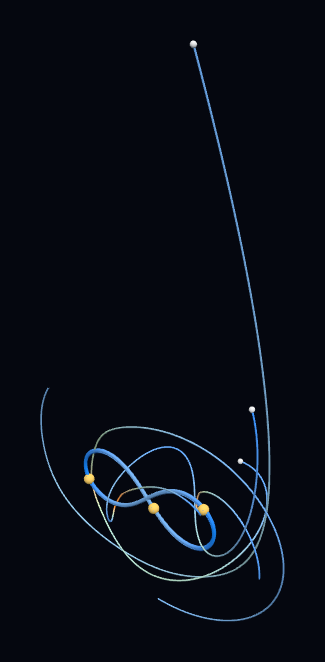

In [11]:
from IPython.display import Image, display

display(Image(filename=str(_repo_root() / "docs" / "assets" / "examples" / "monty_three_orbits.png")))
